<a href="https://colab.research.google.com/github/youkjang/gefs-heavy-precip-verification/blob/main/notebooks/01_open_gefs_precipitation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#NOAA GEFS Precipitation
###Open data & Plot GEFS accumulatd precipitation

##1.Install packages

In [1]:
!pip -q install "eccodes>=2.37.0" cfgrib s3fs "fsspec==2025.3.0"

In [2]:
!pip install cartopy

###2.Import Libraries

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import s3fs
from pathlib import Path

In [4]:
import cartopy.crs as ccrs

###3.Set GEFS case information

In [5]:
init_date = "20260521"   # YYYYMMDD
cycle = "00"             # 00, 06, 12, 18 UTC
member = "c00"           # control member
fhr = 24                 # forecast hour

cache_dir = Path("/content/gefs_precip_cache")
cache_dir.mkdir(exist_ok=True)

fs = s3fs.S3FileSystem(anon=True)

##4.Download one GEFS precipitataion file from Amazon S3

In [6]:
fname = f"ge{member}.t{cycle}z.pgrb2a.0p50.f{fhr:03d}"

s3_key = (
    f"noaa-gefs-pds/gefs.{init_date}/{cycle}/atmos/pgrb2ap5/"
    f"{fname}"
)

local_file = cache_dir / fname

print("S3 path:")
print(s3_key)

if not local_file.exists():
    print(f"Downloading {fname}")
    fs.get(s3_key, str(local_file))
else:
    print(f"Using cached file: {fname}")

local_file

S3 path:
noaa-gefs-pds/gefs.20260521/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f024
Using cached file: gec00.t00z.pgrb2a.0p50.f024


PosixPath('/content/gefs_precip_cache/gec00.t00z.pgrb2a.0p50.f024')

##5.Inspect avaiable GRIB groups


In [7]:
datasets = xr.open_dataset(
    local_file,
    engine="cfgrib",
    backend_kwargs={
        "filter_by_keys": {
            "typeOfLevel": "surface",
            "stepType": "accum"
        },
        "indexpath": ""
    }
)

datasets

<xarray.Dataset> Size: 1MB
Dimensions:     (latitude: 361, longitude: 720)
Coordinates:
  * latitude    (latitude) float64 3kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Data variables:
    tp          (latitude, longitude) float32 1MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-05-22T21:07 GRIB to CDM+CF via cfgrib-0.9.1...

In [8]:
list(datasets.data_vars)

['tp']

##6.Open accumulated precipitation

In [9]:
ds_precip = xr.open_dataset(
    local_file,
    engine="cfgrib",
    backend_kwargs={
        "filter_by_keys": {
            "typeOfLevel": "surface",
            "stepType": "accum"
        },
        "indexpath": ""
    }
)

ds_precip

<xarray.Dataset> Size: 1MB
Dimensions:     (latitude: 361, longitude: 720)
Coordinates:
  * latitude    (latitude) float64 3kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Data variables:
    tp          (latitude, longitude) float32 1MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-05-22T21:07 GRIB to CDM+CF via cfgrib-0.9.1...

In [10]:
precip = ds_precip["tp"]
precip

<xarray.DataArray 'tp' (latitude: 361, longitude: 720)> Size: 1MB
[259920 values with dtype=float32]
Coordinates:
  * latitude    (latitude) float64 3kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Attributes: (12/31)
    GRIB_paramId:                             228228
    GRIB_dataType:                            cf
    GRIB_numberOfPoints:                      259920
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_shortName:                           tp
    GRIB_totalNumber:                         30
    GRIB_units:                               kg m**-2
    long_name:                                Total Precipitation
    units:                                    kg m**-2
    standard_name:                            unknown

##7.Convert precipitation units

In [11]:
precip_mm = precip.copy()
precip_mm.attrs["units"] = "mm"
precip_mm.attrs["long_name"] = "Accumulated precipitation"

##8.Subset CONUS

In [12]:
precip_mm = precip_mm.assign_coords(
    longitude=((precip_mm.longitude + 180) % 360) - 180
).sortby("longitude")

In [13]:
if precip_mm.latitude[0] > precip_mm.latitude[-1]:
    precip_us = precip_mm.sel(
        longitude=slice(-125, -66),
        latitude=slice(50, 24)
    )
else:
    precip_us = precip_mm.sel(
        longitude=slice(-125, -66),
        latitude=slice(24, 50)
    )

precip_us

<xarray.DataArray 'tp' (latitude: 53, longitude: 119)> Size: 25kB
[6307 values with dtype=float32]
Coordinates:
  * latitude    (latitude) float64 424B 50.0 49.5 49.0 48.5 ... 25.0 24.5 24.0
  * longitude   (longitude) float64 952B -125.0 -124.5 -124.0 ... -66.5 -66.0
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Attributes: (12/31)
    GRIB_paramId:                             228228
    GRIB_dataType:                            cf
    GRIB_numberOfPoints:                      259920
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_shortName:                           tp
    GRIB_totalNumber:                         30
    GRIB_units:                               kg m**-2
    long_name:                                Accumulated precipitation
    units:                                    mm
    standard_name:                            unknown

##9.Plot GEFS accumulated precipitation

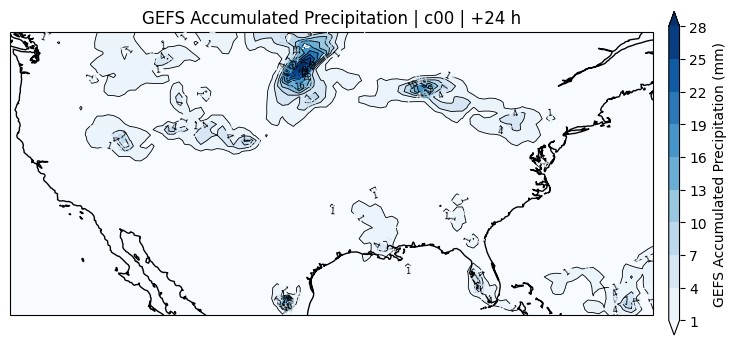

In [16]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10,6))


plot_var = precip_us

contour_levels_temp = np.arange(1, 30, 3)
cs_temp = ax.contourf(plot_var.longitude, plot_var.latitude, plot_var,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          cmap='Blues', extend='both')
cs_temp_contour = ax.contour(plot_var.longitude, plot_var.latitude, plot_var,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          colors='black',linewidths=0.6)
ax.clabel(
    cs_temp_contour,
    inline=True,
    fontsize=6,
    colors='black',
    fmt='%g')

ax.coastlines()
plt.clabel(cs_temp, inline=True, fontsize=8, fmt='%1.0f')

# Add title and colorbar, then show the plot
plt.title(f"GEFS Accumulated Precipitation | {member} | +{fhr} h")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.colorbar(cs_temp, label='GEFS Accumulated Precipitation (mm)',
             pad=0.02, aspect=30,shrink=0.7)

plt.savefig("gefs_precip_example_24h.png", dpi=150, bbox_inches="tight")

plt.show()